In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import sys
sys.path.append('../src/')

In [2]:
# get simulation data for butane, deltanets 
# load the config
import yaml
cfg = yaml.safe_load(open('sim_results/rate_butane_2026-02-20 18:09:38.231662_config.yaml'))
filename = 'sim_results/' + cfg['saved_filename'] + '.npz'
dataname = cfg['data_file']
with np.load(filename, allow_pickle=True) as data:
    trials = data['trials']

In [3]:
trials[20]['committor'].shape


(11570,)

In [4]:
# load data and visualize committor off trials 
delta_data = np.load(dataname, allow_pickle=True)
# data = np.load('butane_metad.npz', allow_pickle=True)
if cfg['flag']: 
    delta_idx = delta_data['net_idx']
    dihedrals = delta_data['dihedrals'][delta_idx]
else:
    delta_idx = delta_data['net_idx']
    dihedrals = delta_data['dihedrals'][-delta_idx.shape[0]:]

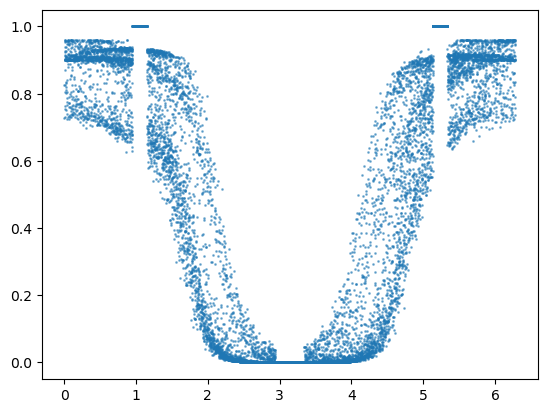

In [5]:
# visualize committor data
plt.scatter(dihedrals, trials[60]['committor'], alpha=0.5, s=1.0)

In [6]:
# load up true committor and get interpolant 
true_committor_data = np.load('dihedral_committor_data.npz', allow_pickle=True)
evaluation_pts = true_committor_data['evaluation_pts']
true_committor = true_committor_data['committor']
from scipy.interpolate import CubicSpline
interpolant = CubicSpline(evaluation_pts, true_committor)
interpolated_committor = interpolant(dihedrals)
target_measure = np.exp(-true_committor_data['free_energy'] / true_committor_data['kbT'])
target_measure_interpolant = CubicSpline(evaluation_pts, target_measure)
interpolated_target_measure = target_measure_interpolant(dihedrals)
Z = (evaluation_pts[1]-evaluation_pts[0])*np.sum(target_measure)

In [7]:
# get errors:
errors = []
for i in range(len(trials)):
    if trials[i]['committor'] is not None: 
        committor_pred = trials[i]['committor']
        error = np.mean((1/Z)*interpolated_target_measure*(committor_pred - interpolated_committor)**2)
        errors.append(error)
    else:
        errors.append(None)


In [8]:
epsilons = []
for i in range(len(trials)):
    epsilons.append(trials[i]['epsilon'])

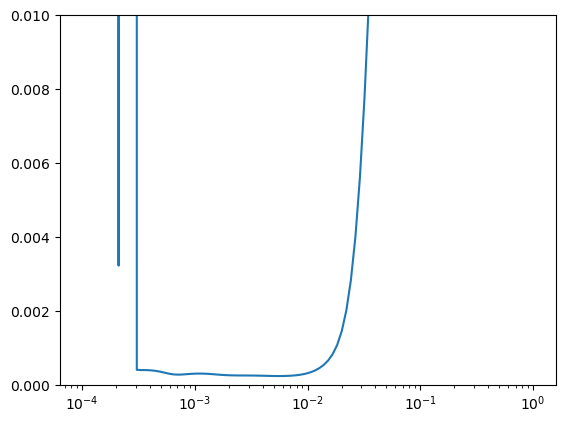

In [9]:
plt.plot(epsilons, errors)
plt.ylim(0.0, 1e-2)
# plt.xlim(2*1e-3, 0.1)
plt.xscale('log')

/tmp/ipykernel_931142/1758098266.py:42: RuntimeWarning: overflow encountered in square
  error_temp = np.mean((1/Z)*interpolated_target_measure_temp*(committor_pred_temp - interpolated_committor_temp)**2)


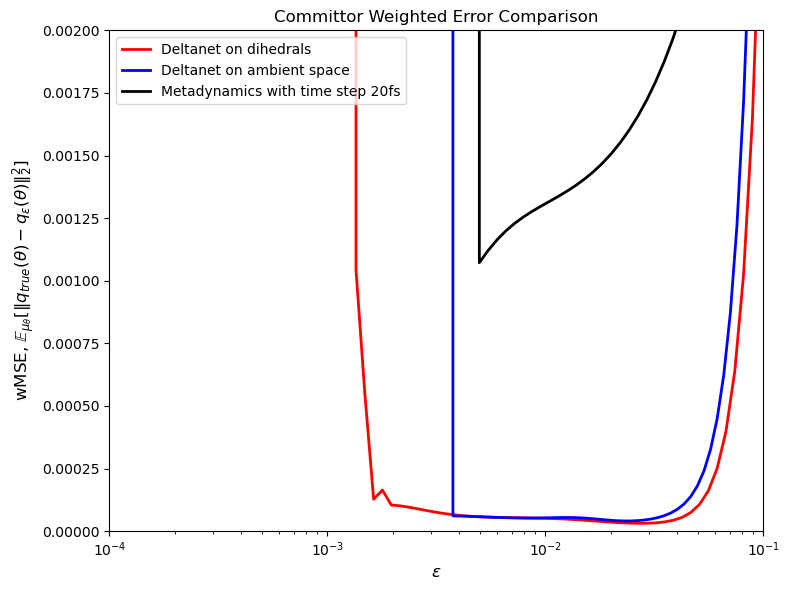

In [11]:
# Load and process both configurations
configs = [
    ('sim_results/rate_butane_2025-12-04 18:58:17.123141_config.yaml', 'Deltanet on dihedrals', 'r'),
    ('sim_results/rate_butane_2025-12-04 17:42:15.689471_config.yaml', 'Deltanet on ambient space', 'b'),
    ('sim_results/rate_butane_2025-12-05 12:51:46.854461_config.yaml', 'Metadynamics with time step 20fs', 'k'),
    # ('sim_results/rate_butane_2026-02-20 18:09:38.231662_config.yaml', 'Deltanet on aligned distances', 'g'),
]

all_errors = []
all_epsilons = []

for config_file, label, color in configs:
    # Load the config
    cfg_temp = yaml.safe_load(open(config_file))
    filename_temp = 'sim_results/' + cfg_temp['saved_filename'] + '.npz'
    dataname_temp = cfg_temp['data_file']
    
    # Load trials
    with np.load(filename_temp, allow_pickle=True) as data_temp:
        trials_temp = data_temp['trials']
    
    # Load data and get dihedrals
    delta_data_temp = np.load(dataname_temp, allow_pickle=True)
    if cfg_temp['flag']: 
        delta_idx_temp = delta_data_temp['net_idx']
        dihedrals_temp = delta_data_temp['dihedrals'][delta_idx_temp]
    else:
        delta_idx_temp = delta_data_temp['net_idx']
        dihedrals_temp = delta_data_temp['dihedrals'][-delta_idx_temp.shape[0]:]
    
    # Interpolate true committor and target measure at the relevant dihedrals
    interpolated_committor_temp = interpolant(dihedrals_temp)
    interpolated_target_measure_temp = target_measure_interpolant(dihedrals_temp)
    
    # Compute weighted errors
    errors_temp = []
    epsilons_temp = []
    for i in range(len(trials_temp)):
        epsilons_temp.append(trials_temp[i]['epsilon'])
        if trials_temp[i]['committor'] is not None: 
            committor_pred_temp = trials_temp[i]['committor']
            error_temp = np.mean((1/Z)*interpolated_target_measure_temp*(committor_pred_temp - interpolated_committor_temp)**2)
            errors_temp.append(error_temp)
        else:
            errors_temp.append(None)
    
    all_errors.append(errors_temp)
    all_epsilons.append(epsilons_temp)

# Plot both error curves
plt.figure(figsize=(8, 6))
for i, (config_file, label, color) in enumerate(configs):
    plt.plot(all_epsilons[i], all_errors[i], label=label, c=color, linewidth=2)

plt.xlabel(r'$\varepsilon$', fontsize=12)
plt.ylabel(r'wMSE, $\mathbb{E}_{\mu_{\theta}}[\|q_{true}(\theta) - q_{\epsilon}(\theta)\|_{2}^{2}]$', fontsize=12)
plt.ylim(0.0, 2*1e-3)
plt.xlim(1e-4, 1e-1)
plt.xscale('log')
# plt.yscale('log')
plt.legend()
# plt.grid(True, alpha=0.3)
plt.title('Committor Weighted Error Comparison')
plt.tight_layout()
plt.show()

In [ ]:
# Load and process both configurations
configs = [
    ('sim_results/rate_butane_2025-12-04 18:58:17.123141_config.yaml', 'Deltanet on dihedrals', 'r', 50),
    ('sim_results/rate_butane_2025-12-04 17:42:15.689471_config.yaml', 'Deltanet on ambient space', 'b', 50),
    ('sim_results/rate_butane_2025-12-05 12:51:46.854461_config.yaml', 'Metadynamics with time step 20fs', 'k', 40)
]

all_committors = []
# all_epsilons = []

for config_file, label, color in configs:
    # Load the config
    cfg_temp = yaml.safe_load(open(config_file))
    filename_temp = cfg_temp['saved_filename'] + '.npz'
    dataname_temp = cfg_temp['data_file']
    
    # Load trials
    with np.load(filename_temp, allow_pickle=True) as data_temp:
        trials_temp = data_temp['trials']
    
    # Load data and get dihedrals
    delta_data_temp = np.load(dataname_temp, allow_pickle=True)
    if cfg_temp['flag']: 
        delta_idx_temp = delta_data_temp['net_idx']
        dihedrals_temp = delta_data_temp['dihedrals'][delta_idx_temp]
    else:
        delta_idx_temp = delta_data_temp['net_idx']
        dihedrals_temp = delta_data_temp['dihedrals'][-delta_idx_temp.shape[0]:]
    
    # Interpolate true committor and target measure at the relevant dihedrals
    interpolated_committor_temp = interpolant(dihedrals_temp)
    interpolated_target_measure_temp = target_measure_interpolant(dihedrals_temp)